## Carga de datos y librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [2]:
path = '/Users/alberth/Documents/Pruebas python/Prueba Artefact/data_customers.csv'
df = pd.read_csv(path)
df

,fullVisitorId,channelGrouping,weekend_prop,hour,sessionId,device.browser,device.deviceCategory,device.isMobile,device.operatingSystem,totals.hits,totals.pageviews,bounce_prop,trafficSource.medium
0,213131142648941,Direct,0.000000,22.0,1,Chrome,desktop,0.0,Macintosh,14.0,13.0,0.0,(none)
1,435324061339869,Referral,0.666667,21.0,3,Chrome,desktop,0.0,Macintosh,14.0,11.0,0.0,referral
2,562678147042735,Organic Search,0.000000,14.0,2,Chrome,desktop,0.0,Macintosh,12.5,10.5,0.0,organic
3,585708896049892,Referral,0.000000,20.0,1,Chrome,desktop,0.0,Linux,22.0,20.0,0.0,referral
4,670722016498267,Referral,0.000000,17.0,2,Chrome,desktop,0.0,Linux,9.5,9.5,0.0,referral
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,9991633376050115277,Social,0.000000,0.0,1,Chrome,desktop,0.0,Linux,17.0,16.0,0.0,referral
9992,9994767073213036303,Organic Search,0.000000,20.0,5,Chrome,desktop,0.0,Windows,42.0,30.0,0.0,organic
9993,9997409246962677759,Referral,0.000000,2.0,1,Chrome,desktop,0.0,Macintosh,86.0,65.0,0.0,referral
9994,9998597322098588317,Direct,0.000000,21.0,1,Chrome,desktop,0.0,Macintosh,37.0,33.0,0.0,(none)


## Análisis Exploratorio de Datos (EDA)

En esta sección haremos lo siguiente:
* Revisaremos columna por columna para verificar si hay inconsistencias o valores faltantes camuflados. 
* Corregiremos lo que deba ser corregido.
* Graficarémos las distribuciones y calcularemos estadísticos para observar diferentes tendencias.

In [3]:
# Ajustamos el nombre de las columnas por comodidad
df.columns = df.columns.str.replace('.','_')
df = df.rename(columns={'device_deviceCategory':'device_category'})

### channelGrouping

In [4]:
df.channelGrouping.unique()

<StringArray>
[        'Direct',       'Referral', 'Organic Search',        'Display',
    'Paid Search',         'Social',     'Affiliates',        '(Other)']
Length: 8, dtype: str

In [5]:
# Cambiamos los valores '(Other)'
df.channelGrouping = df.channelGrouping.replace('(Other)', 'Other')

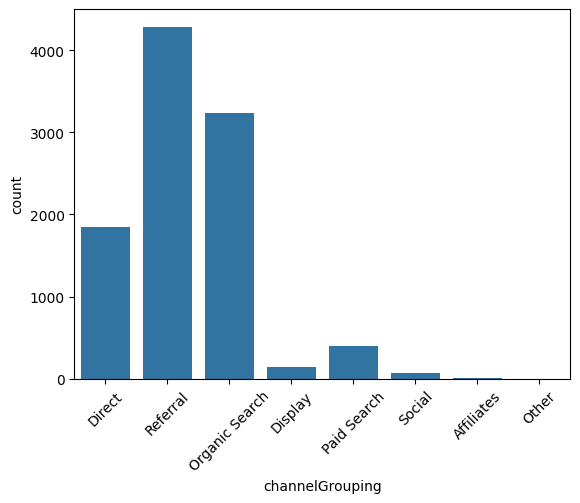

In [6]:
sns.countplot(data=df, x='channelGrouping')
plt.xticks(rotation=45)
plt.show()

In [7]:
round(df.channelGrouping.value_counts(normalize=True),2)

channelGrouping
Referral          0.43
Organic Search    0.32
Direct            0.19
Paid Search       0.04
Display           0.01
Social            0.01
Affiliates        0.00
Other             0.00
Name: proportion, dtype: float64

Se evidencia que la mayor parte del tráfico proviene de Referidos (43%), seguido por Búsquedas Orgánicas (32%) y Tráfico Directo (19%). Esto indica que el sitio cuenta con un buen posicionamiento y reconocimiento de marca, dependiendo en menor medida de los canales de pauta paga (Paid Search, Display, Social y Afiliados), los cuales representan en conjunto menos del 6% del tráfico total.

### weekend_prop

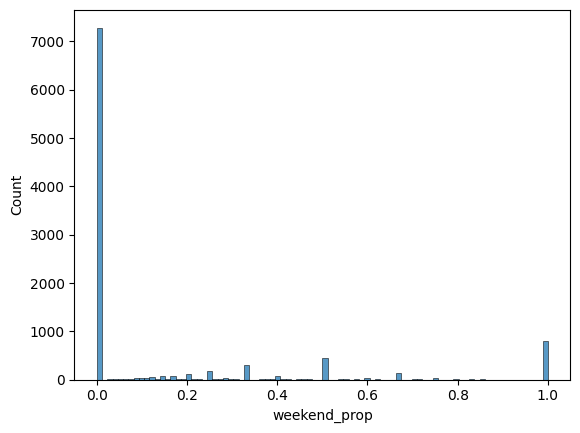

In [8]:
sns.histplot(data=df, x='weekend_prop')
plt.show()

In [9]:
df.weekend_prop.describe()

count    9996.000000
mean        0.147011
std         0.296219
min         0.000000
25%         0.000000
50%         0.000000
75%         0.126359
max         1.000000
Name: weekend_prop, dtype: float64

Se evidencia que la gran mayoría de visitas ocurren entre semana y no los sabados o domingos.

### hour

In [10]:
df.hour.describe()

count    9996.000000
mean       14.449030
std         6.261204
min         0.000000
25%        11.000000
50%        16.500000
75%        19.000000
max        23.000000
Name: hour, dtype: float64

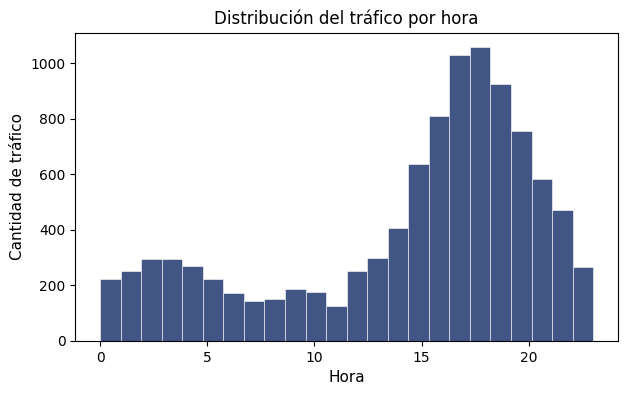

In [11]:
plt.figure(figsize=(7,4))

sns.histplot(data=df, x='hour', bins=24, color="#021E5C", edgecolor="white", linewidth = 0.4)
plt.title('Distribución del tráfico por hora',fontsize=12)
plt.xlabel('Hora',fontsize=11)
plt.ylabel('Cantidad de tráfico',fontsize=11)
#plt.savefig('grafico_hour.png', dpi=300, bbox_inches='tight')
plt.show()

En este gráfico se observa una clara tendencia en el tráfico de visitas a la página, mostrando un incremento alrededor de las 12:00 del día y alcanzando su pico más alto entre las 17:00 y las 18:00.
Este comportamiento revela un perfil de usuario activo principalmente durante la segunda jornada del horario laboral y el regreso a casa, aunque tambien evidencia ligeros aumentos de navegación en la madrugada. 

Por otro lado, las horas con el tráfico de visitas más bajo ocurre entre las 6:00 y las 11:00, sugiriendo que se debe evitar invertir en publicidad en estos horarios en caso de que se esté haciendo.

### device_browser

In [12]:
df.device_browser.unique()

<StringArray>
[           'Chrome',            'Safari',           'Firefox',
              'Edge', 'Internet Explorer',             'Opera',
   'Safari (in-app)',       'Amazon Silk',   'Android Webview']
Length: 9, dtype: str

In [13]:
# Estandarizamos los valores de 'Safari' en una sola categoría
df.device_browser = df.device_browser.replace('Safari (in-app)', 'Safari')

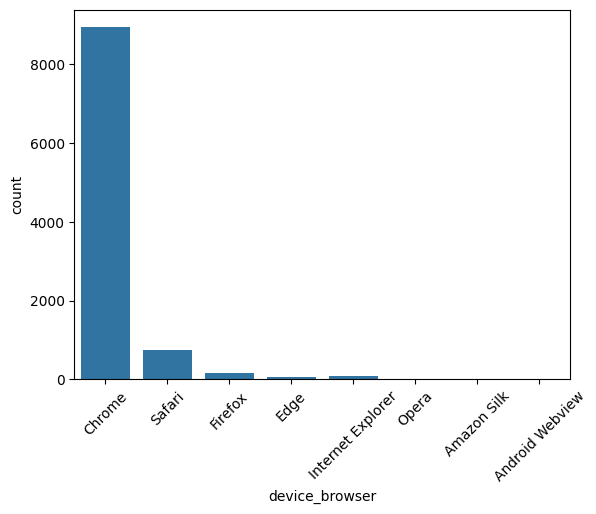

In [14]:
sns.countplot(data=df, x='device_browser')
plt.xticks(rotation=45)
plt.show()

In [15]:
round(df.device_browser.value_counts(normalize=True),2)

device_browser
Chrome               0.89
Safari               0.07
Firefox              0.02
Internet Explorer    0.01
Edge                 0.01
Android Webview      0.00
Opera                0.00
Amazon Silk          0.00
Name: proportion, dtype: float64

Se observa que la mayor parte del tráfico (casi el 90%) ocurre en el navegador Chrome, seguido por Safari con un 7% y los demás canales que en conjunto no superan el 4%. Por esta razón, se agrupará este conjunto de navegadores minoritarios en una sola categoría llamada "Others".

In [16]:
df.device_browser = df.device_browser.where(df.device_browser.isin(['Chrome', 'Safari']), 'Others')

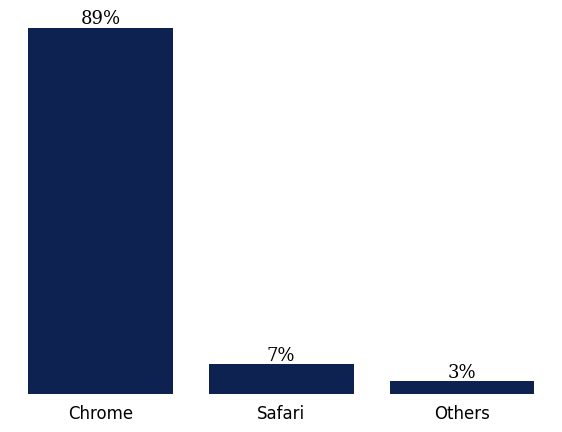

In [17]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='device_browser', color="#021E5C")

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%" for p in ax.patches]
ax.bar_label(ax.containers[0], labels=etiquetas,label_type='edge' , color='k', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

### device_category

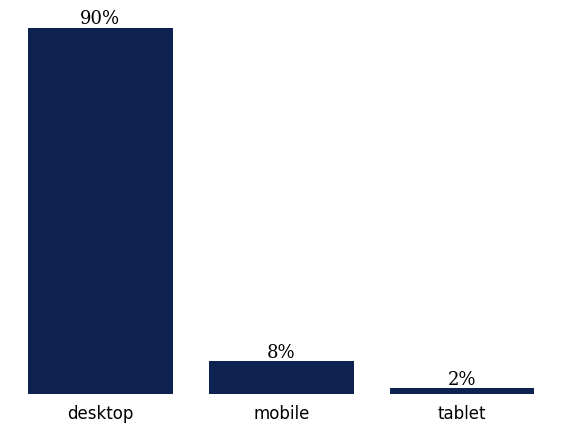

In [18]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='device_category', color="#021E5C")

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%" for p in ax.patches]
ax.bar_label(ax.containers[0], labels=etiquetas,label_type='edge' , color='k', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

Se evidencia que la mayor parte del tráfico (90%) ocurre desde computadores de escritorio (desktop), en menor medida desde dispositivos móviles (8%) y con una participación mínima desde tabletas (2%).

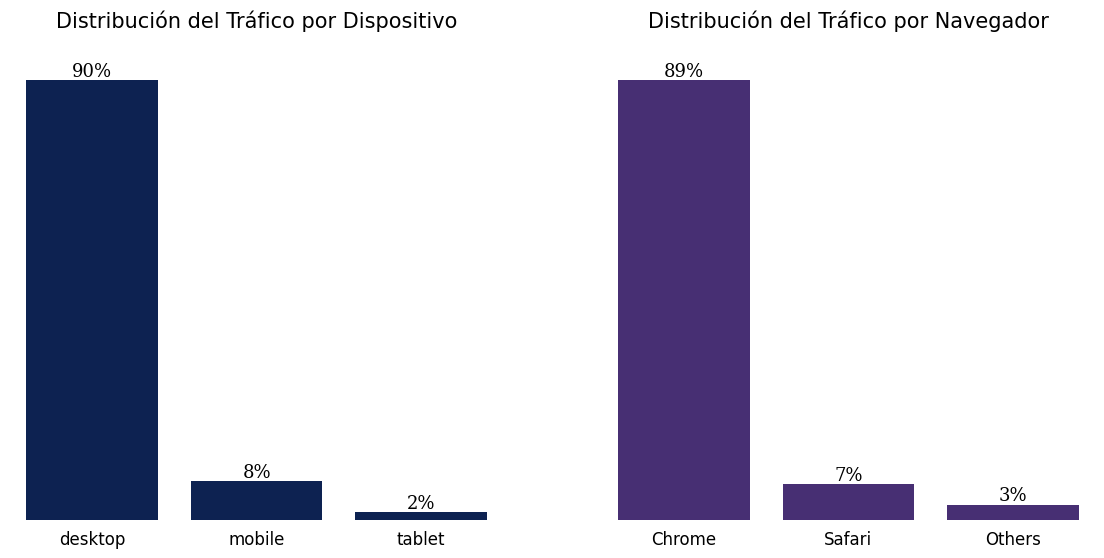

In [19]:
################## GRAFICO PARA EL INFORME ##################

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
ax1 = sns.countplot(data=df, x='device_category', color="#021E5C")
ax1.set_yticks([])
ax1.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)
total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%" for p in ax1.patches]
ax1.bar_label(ax1.containers[0], labels=etiquetas,label_type='edge' , color='k', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_title('Distribución del Tráfico por Dispositivo\n', fontsize=15)

plt.subplot(1,2,2)
ax2 = sns.countplot(data=df, x='device_browser', color="#44247ED9")
ax2.set_yticks([])
ax2.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)
total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%" for p in ax2.patches]
ax2.bar_label(ax2.containers[0], labels=etiquetas,label_type='edge' , color='k', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_title('Distribución del Tráfico por Navegador\n', fontsize=15)

plt.subplots_adjust(wspace=0.2)
#plt.savefig('grafico_dispositivo_y_navegador.png', dpi=300, bbox_inches='tight')
plt.show()

################## GRAFICO PARA EL INFORME ##################

### device_isMobile

In [20]:
df.device_isMobile.unique()

array([0.        , 1.        , 0.5       , 0.66666667, 0.83333333,
       0.30769231])

Se eliminará esta columna ya que se esperaban valores tipo one-hot pero se observan en su lugar valores decimales.
De todas formas la información del dispositivo ya está capturada por la columna device_category.

In [21]:
df = df.drop(columns='device_isMobile')

### device_operatingSystem

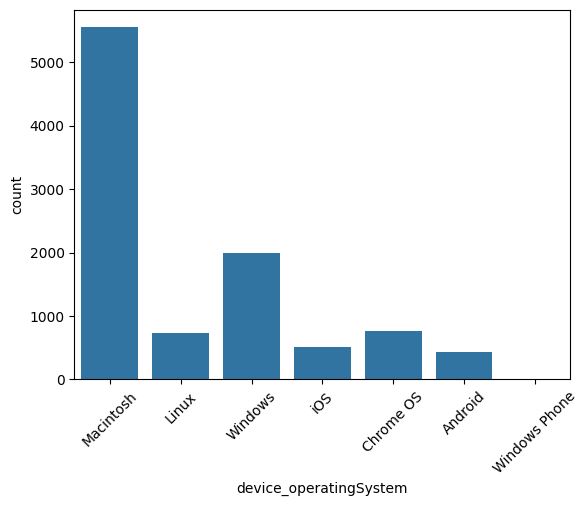

In [22]:
sns.countplot(data=df, x='device_operatingSystem')
plt.xticks(rotation = 45)
plt.show()

In [23]:
round(df.device_operatingSystem.value_counts(normalize=True), 2)

device_operatingSystem
Macintosh        0.56
Windows          0.20
Chrome OS        0.08
Linux            0.07
iOS              0.05
Android          0.04
Windows Phone    0.00
Name: proportion, dtype: float64

Se observa que la mayor parte del tráfico ocurre desde sistemas operativos Macintosh (56%), seguido por Windows (20%). 

Dado que las categorías restantes que incluyen sistemas operativos de escritorio menores y sistemas operativos móviles (Chrome OS, Linux, iOS, Android y Windows Phone) representan individualmente 8% del tráfico o menos, se toma la decisión de agruparlas en una sola categoría llamada 'Others'.

In [24]:
df.device_operatingSystem = df.device_operatingSystem.where(df.device_operatingSystem.isin(['Macintosh', 'Windows']), 'Others')

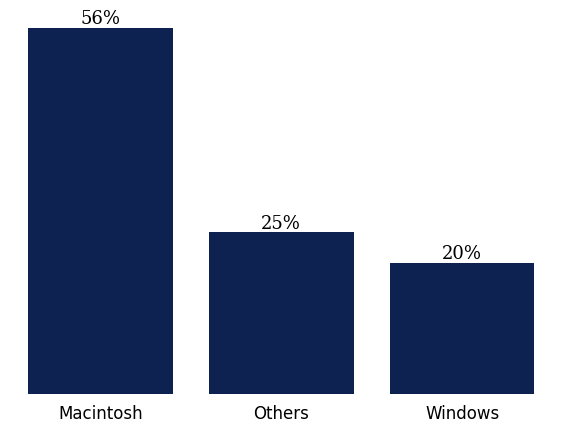

In [25]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='device_operatingSystem', color="#021E5C")

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%" for p in ax.patches]
ax.bar_label(ax.containers[0], labels=etiquetas,label_type='edge' , color='k', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

### totals_hits

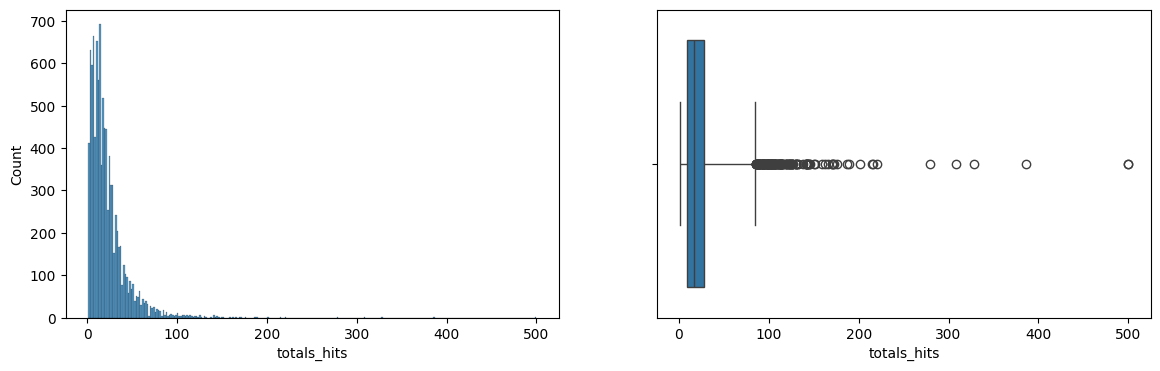

In [26]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(data=df, x='totals_hits')
plt.subplot(1,2,2)
sns.boxplot(data=df,x='totals_hits', whis=3)
plt.show()

In [27]:
df.totals_hits.describe()

count    9996.000000
mean       22.177771
std        21.916773
min         1.000000
25%         9.000000
50%        17.000000
75%        28.000000
max       500.000000
Name: totals_hits, dtype: float64

In [28]:
q_99 = df.totals_hits.quantile(q=0.99)
q_99

101.0

Se observa que hay un 25% de las interacciones que supera los 28 hits y solo el 1% supera los 101. Por lo tanto, para evitar que estos outliers distorsionen el cálculo de las distancias al hacer el clustering, eliminaremos este sesgo acotando este 1% superior al limite de 101.

In [29]:
df.totals_hits = df.totals_hits.clip(upper=q_99)

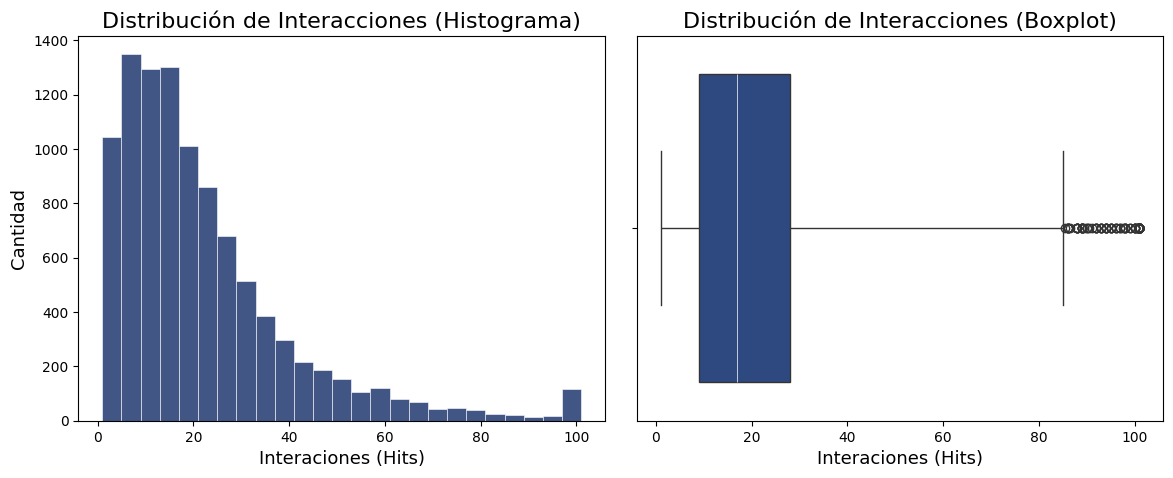

In [30]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(data=df, x='totals_hits', bins=25, color="#021E5C", edgecolor="white", linewidth = 0.4)
plt.title('Distribución de Interacciones (Histograma)', fontsize=16)
plt.xlabel('Interaciones (Hits)',fontsize=13)
plt.ylabel('Cantidad',fontsize=13)

plt.subplot(1,2,2)
sns.boxplot(data=df, x='totals_hits', whis=3, color="#21448DFF", medianprops={'color': 'white', 'linewidth': 0.5})
plt.title('Distribución de Interacciones (Boxplot)',fontsize=16)
plt.xlabel('Interaciones (Hits)',fontsize=13)
plt.subplots_adjust(wspace=0.06)
#plt.savefig('grafico_hits.png', dpi=300, bbox_inches='tight')
plt.show()

### totals_pageviews

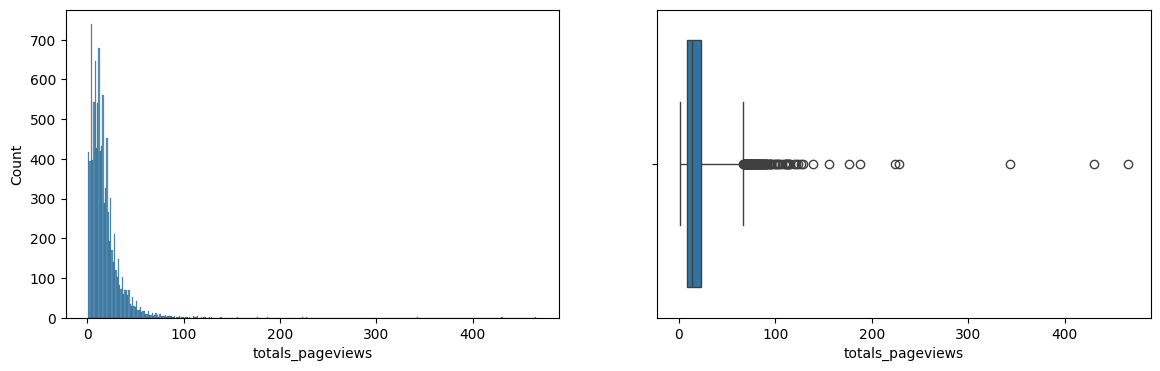

In [31]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(data=df, x='totals_pageviews')
plt.subplot(1,2,2)
sns.boxplot(data=df,x='totals_pageviews', whis=3)
plt.show()

In [32]:
df.totals_pageviews.describe()

count    9996.000000
mean       17.530312
std        16.259149
min         1.000000
25%         8.000000
50%        14.000000
75%        22.500000
max       466.000000
Name: totals_pageviews, dtype: float64

In [33]:
q99_pv = df.totals_pageviews.quantile(q=0.99)
q99_pv

71.04999999999927

En este caso ocurre algo similar al total de interacciones, ya que podemos notar que hay un 25% del total de páginas vistas en la sesión que es superior a 22.5, y solo el 1% es superior a 71. Por lo tanto, procediendo de manera similar a como lo hicimos antes, acotaremos este 1% superior a un límite de 71.

In [34]:
df.totals_pageviews = df.totals_pageviews.clip(upper=q99_pv)

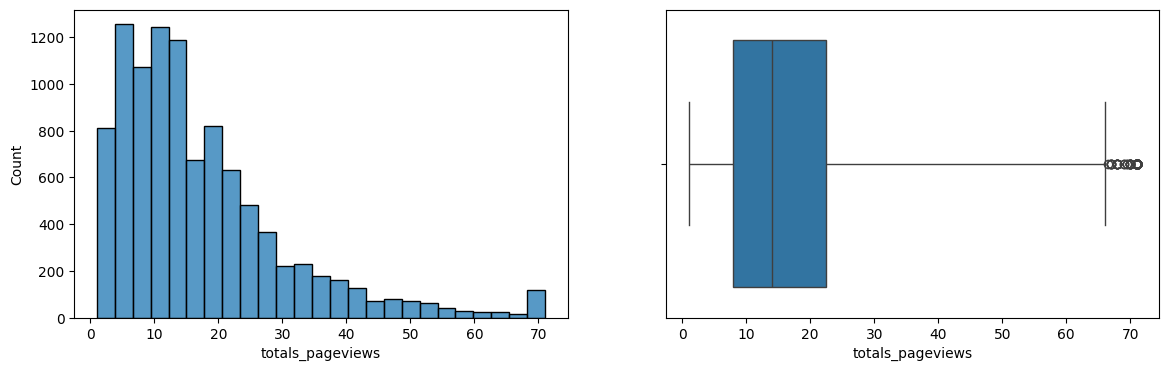

In [35]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(data=df, x='totals_pageviews', bins=25)
plt.subplot(1,2,2)
sns.boxplot(data=df,x='totals_pageviews', whis=3)
plt.show()

### bounce_prop

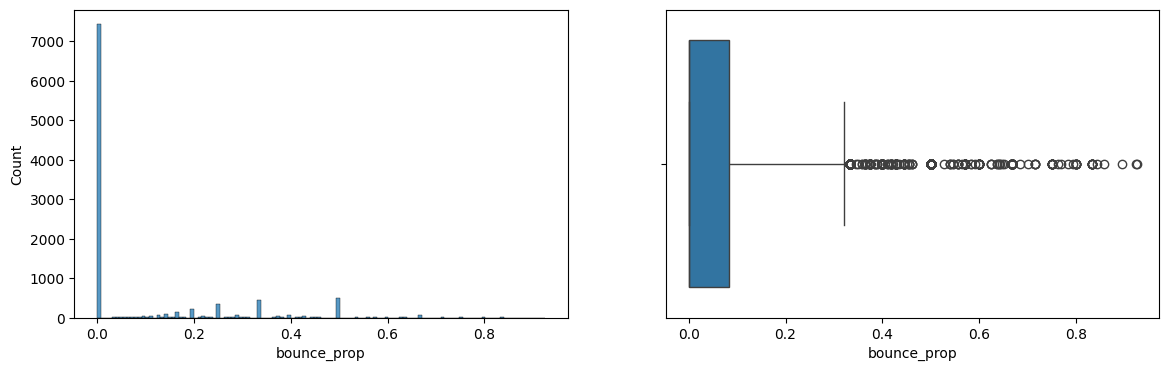

In [36]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(data=df, x='bounce_prop')
plt.subplot(1,2,2)
sns.boxplot(data=df,x='bounce_prop', whis=3)
plt.show()

In [37]:
df.bounce_prop.describe()

count    9996.000000
mean        0.082718
std         0.162298
min         0.000000
25%         0.000000
50%         0.000000
75%         0.083333
max         0.925373
Name: bounce_prop, dtype: float64

In [38]:
prop_rebotes = df[df.bounce_prop>0].shape[0] / df.shape[0]
print("Proporción de rebotes diferente de cero:",round(prop_rebotes,3))

Proporción de rebotes diferente de cero: 0.257


Se observa que aproximadamente el 75% de los usuarios no rebotó nunca, lo cual es un indicador positivo de la calidad del tráfico ya que confirma que la mayoría de los visitantes interactuan realmente con la página.

### trafficSource_medium

In [39]:
df.trafficSource_medium.unique()

<StringArray>
['(none)', 'referral', 'organic', 'cpm', 'cpc', 'affiliate', '(not set)']
Length: 7, dtype: str

Se evidencian inconsistencias como (none) y (not set)

In [40]:
# Renombramos el valor de (none)
df.trafficSource_medium = df.trafficSource_medium.replace('(none)', 'direct')

In [41]:
# Revisamos los valores etiquetados como (not set)
df[df.trafficSource_medium == '(not set)']

,fullVisitorId,channelGrouping,weekend_prop,hour,sessionId,device_browser,device_category,device_operatingSystem,totals_hits,totals_pageviews,bounce_prop,trafficSource_medium
9902,9907138721210043039,Other,0.0,19.0,1,Chrome,mobile,Others,17.0,16.0,0.0,(not set)


Dado que hay un único registro etiquetado como '(not set)', procedemos a eliminarlo.

In [42]:
df = df[df.trafficSource_medium != '(not set)']
df = df.reset_index(drop=True)

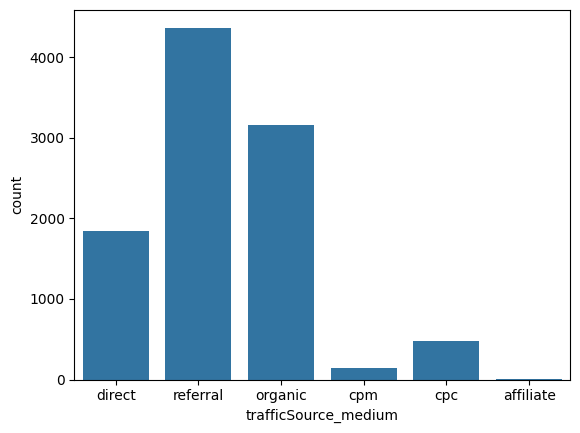

In [43]:
sns.countplot(data=df, x='trafficSource_medium')
plt.show()

Agrupamos las categorías de cpm, cpc y affiliate en una sola categoría llamada paid.

In [44]:
df.trafficSource_medium = df.trafficSource_medium.replace(['cpc', 'cpm', 'affiliate'], 'paid')

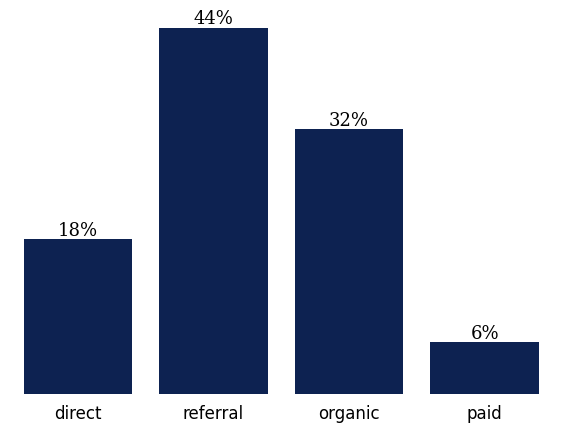

In [45]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='trafficSource_medium', color="#021E5C")

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%" for p in ax.patches]
ax.bar_label(ax.containers[0], labels=etiquetas,label_type='edge' , color='k', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

Esta columna aporta practicamente la información que la columna channelGrouping, así que para el clustering tomaremos solo esta pues ya la tenemos agrupada.

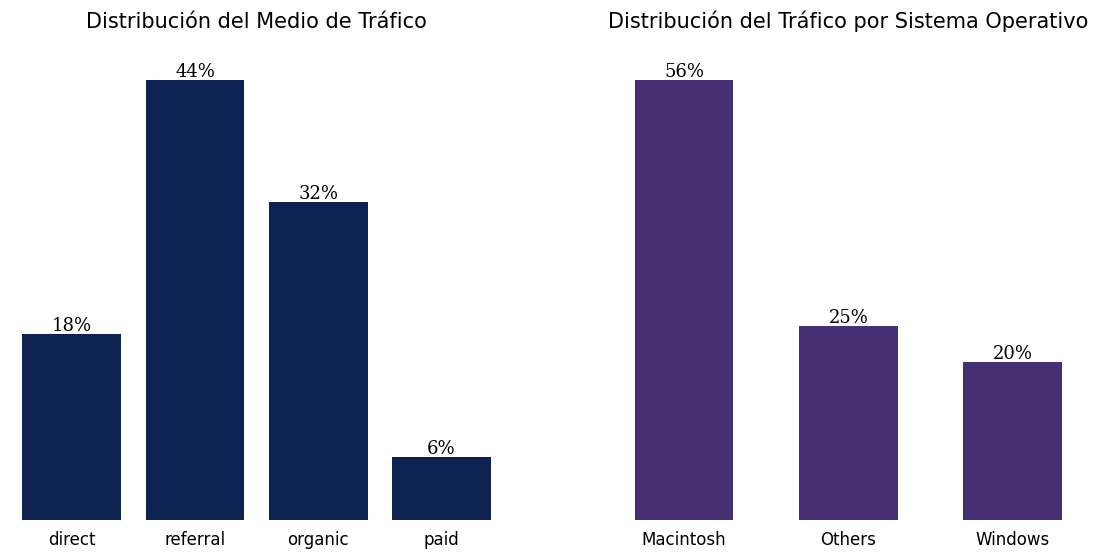

In [46]:
################## GRAFICO PARA EL INFORME ##################

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
ax1 = sns.countplot(data=df, x='trafficSource_medium', color="#021E5C")
ax1.set_yticks([])
ax1.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)
total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%" for p in ax1.patches]
ax1.bar_label(ax1.containers[0], labels=etiquetas,label_type='edge' , color='k', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_title('Distribución del Medio de Tráfico\n', fontsize=15)

plt.subplot(1,2,2)
ax2 = sns.countplot(data=df, x='device_operatingSystem', color="#44247ED9", width=0.6)
ax2.set_yticks([])
ax2.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)
total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%" for p in ax2.patches]
ax2.bar_label(ax2.containers[0], labels=etiquetas,label_type='edge' , color='k', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_title('Distribución del Tráfico por Sistema Operativo\n', fontsize=15)

plt.subplots_adjust(wspace=0.2)
#plt.savefig('grafico_medio_traf_y_sistema_operativo.png', dpi=300, bbox_inches='tight')
plt.show()

################## GRAFICO PARA EL INFORME ##################

### hour - device_browser

Ahora, dado que los usuarios de Chrome son casi el 90% del conjunto de datos, la distribución de la columna "hour" vista hace unos momentos está fuertemente influenciada por este grupo. Así que, para verificar si existe algún patrón diferente en otro navegador graficaremos la distribución enfocandonos únicamente en dicho navegador.

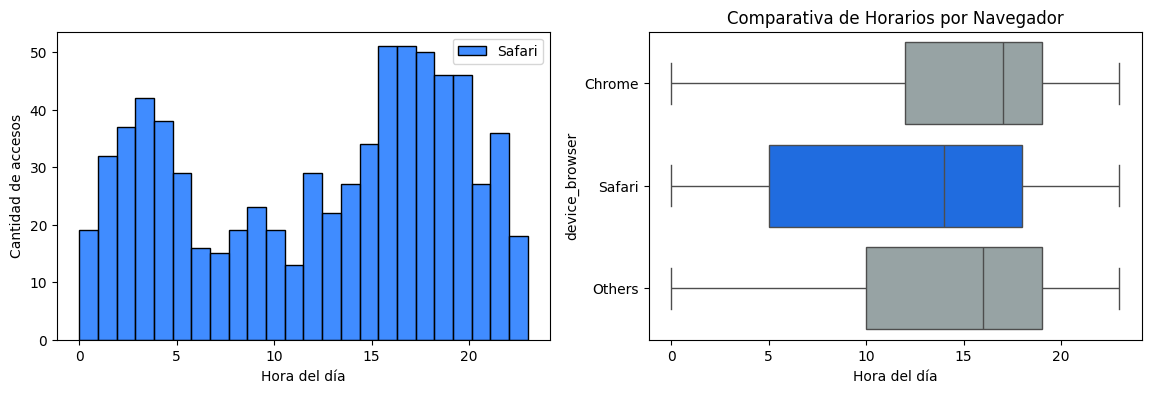

In [47]:
colores_navegadores = {
    'Chrome': '#95A5A6',   
    'Safari': '#0066FF',   
    'Others': '#95A5A6'   
}

plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(data=df[df.device_browser=='Safari'], x='hour', bins=24, label='Safari', color='#0066FF')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de accesos')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(data=df,x='hour', whis=3, y='device_browser', hue='device_browser', palette=colores_navegadores)
plt.title('Comparativa de Horarios por Navegador')
plt.xlabel('Hora del día')
plt.show()

Este histograma nos permite ver que los usuarios de Safari presentan una distribución más bimodal, en la cual se evidencian dos picos más similares de actividad: uno alrededor de las 3:00 - 4:00 y otro alrededor de las 16:00 - 18:00.

### hour - device_operatingSystem

Verifiquemos ahora si existe un patron oculto en la distribucion de la hora según el sistema operativo.

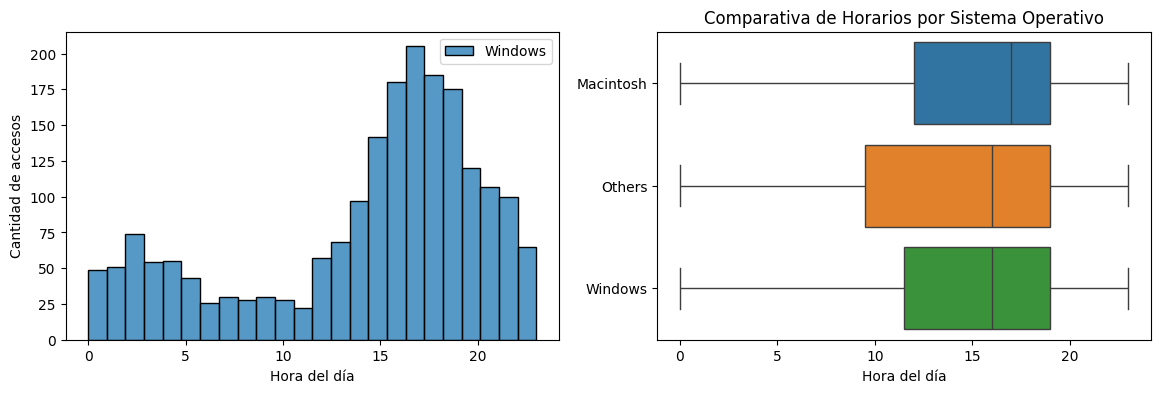

In [48]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(data=df[df.device_operatingSystem=='Windows'], x='hour', bins=24, label = 'Windows')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de accesos')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(data=df,x='hour', whis=3, y='device_operatingSystem', hue='device_operatingSystem')
plt.title('Comparativa de Horarios por Sistema Operativo')
plt.xlabel('Hora del día')
plt.ylabel(None)
plt.show()

No se observa un patron diferente al separar por el sistema operativo.

### device_operatingSystem - trafficSource_medium

In [49]:
round(pd.crosstab(index=df.device_operatingSystem, columns=df.trafficSource_medium,normalize='index'),2)

trafficSource_medium,direct,organic,paid,referral
device_operatingSystem,,,,
Macintosh,0.16,0.24,0.05,0.56
Others,0.21,0.34,0.08,0.37
Windows,0.23,0.51,0.07,0.19


Se observa cómo la mayoría de usuarios Macintosh llegan al sitio web por medio de referidos (56%), mientras que en los usuarios Windows predomina notablemente el tráfico orgánico (51%), seguido del tráfico directo (23%).

### device_operatingSystem - device_browser

In [50]:
round(pd.crosstab(index=df.device_operatingSystem, columns=df.device_browser,normalize='index'),2)

device_browser,Chrome,Others,Safari
device_operatingSystem,,,
Macintosh,0.94,0.01,0.06
Others,0.82,0.00,0.17
Windows,0.87,0.13,0.00


### device_browser - trafficSource_medium

In [51]:
round(pd.crosstab(index=df.device_browser, columns=df.trafficSource_medium,normalize='index'),2)

trafficSource_medium,direct,organic,paid,referral
device_browser,,,,
Chrome,0.18,0.28,0.06,0.49
Others,0.30,0.59,0.08,0.03
Safari,0.20,0.67,0.10,0.03


En este caso observamos que casi la mitad de los que usan Chrome llegan por referidos (49%), mientras que los de Safari y otros navegadores lo hacen principalmente por búsquedas orgánicas (67% y 59% respectivamente).

### device_category Vs trafficSource_medium

In [52]:
round(pd.crosstab(index=df.device_category, columns=df.trafficSource_medium,normalize='index'),2)

trafficSource_medium,direct,organic,paid,referral
device_category,,,,
desktop,0.18,0.29,0.06,0.48
mobile,0.26,0.58,0.13,0.02
tablet,0.22,0.62,0.11,0.04


De esta tabla podemos notar principalmente que los usuarios de dispositivos móviles y tablets acceden al sitio web en gran medida por busquedas orgánicas (58% y 62% respectivamente). Por el contrario, en los usuarios de escritorio predomina el tráfico de referidos con un 48%, seguido de busquedas orgánicas con un 29%.

## Preprocesamiento de Datos

En esta sección haremos algunas transformaciones sobre las variables como:
- una transformación logaritmica sobre aquellas variables que presentan un fuerte sesgo
- el escalamiento de las variables numéricas
- la codificación de las variables categóricas
- eliminaremos las columnas que no aportan información relevante.

Eliminamos las columnas de IDs y también la de channelGrouping pues vimos que esta última aporta la misma información que trafficSource_medium.

In [53]:
df = df.drop(columns=['fullVisitorId', 'sessionId', 'channelGrouping'])
df_temporal = df.copy()

Realizamos una transformacion logaritmica sobre las columnas totals_hits y totals_pageviews dado que vimos que estas presentan un fuerte sesgo a la derecha.

In [54]:
df_temporal['totals_hits_log'] = np.log1p(df_temporal.totals_hits)
df_temporal['totals_pageviews_log'] = np.log1p(df_temporal.totals_pageviews)

# Eliminamos las columnas transformadas
df_temporal = df_temporal.drop(columns=['totals_hits', 'totals_pageviews'])

Realizamos el escalamiento de las columnas numéricas y el one-hot encoding de las categóricas

In [55]:
# Separamos numericas y categoricas
num_cols = df_temporal.select_dtypes(['number']).columns.to_list()
cat_cols = df_temporal.select_dtypes(['str']).columns.to_list()

scaler = MinMaxScaler()

# Transformamos
df_num_escalado = pd.DataFrame(scaler.fit_transform(df_temporal[num_cols]), columns=num_cols)
df_dummies = pd.get_dummies(df_temporal[cat_cols])*1

# Concatenamos
X = pd.concat([df_num_escalado,df_dummies],axis=1)

In [56]:
X # Dataset final para hacer el clustering

,weekend_prop,hour,bounce_prop,totals_hits_log,totals_pageviews_log,device_browser_Chrome,device_browser_Others,device_browser_Safari,device_category_desktop,device_category_mobile,device_category_tablet,device_operatingSystem_Macintosh,device_operatingSystem_Others,device_operatingSystem_Windows,trafficSource_medium_direct,trafficSource_medium_organic,trafficSource_medium_paid,trafficSource_medium_referral
0,0.000000,0.956522,0.0,0.512460,0.542911,1,0,0,1,0,0,1,0,0,1,0,0,0
1,0.666667,0.913043,0.0,0.512460,0.499903,1,0,0,1,0,0,1,0,0,0,0,0,1
2,0.000000,0.608696,0.0,0.485663,0.488029,1,0,0,1,0,0,1,0,0,0,1,0,0
3,0.000000,0.869565,0.0,0.621174,0.656037,1,0,0,1,0,0,0,1,0,0,0,0,1
4,0.000000,0.739130,0.0,0.421745,0.462648,1,0,0,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9990,0.000000,0.000000,0.0,0.558831,0.597081,1,0,0,1,0,0,0,1,0,0,0,0,1
9991,0.000000,0.869565,0.0,0.780313,0.764698,1,0,0,1,0,0,0,0,1,0,1,0,0
9992,0.000000,0.086957,0.0,0.959544,0.975530,1,0,0,1,0,0,1,0,0,0,0,0,1
9993,0.000000,0.913043,0.0,0.748873,0.790470,1,0,0,1,0,0,1,0,0,1,0,0,0


## Segmentación de Clientes

En esta sección relizaremos un K-means con los respectivos gráficos de codo y de silueta y adicionalmente un dendograma para elegir el número optimo de clusters.

### K-means

Realizamos un gráfico de codo para elegir el número adecuado de clusters.

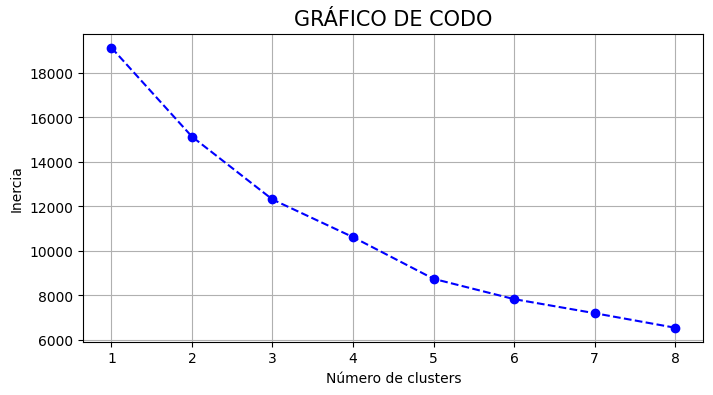

In [57]:
inertias = []
for i in range(1,9):
    km_ = KMeans(n_clusters=i,
            init='k-means++',
            n_init=10,        
            max_iter=300,
            tol=0.0001,
            random_state=0)
    km_.fit(X)
    inertias.append(km_.inertia_)
    
plt.figure(figsize=(8, 4))    
plt.plot(range(1,9), inertias, marker='o', c='b', linestyle='--')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('GRÁFICO DE CODO', fontsize=15)
plt.grid(True)
plt.show()

Se observa un ligero codo en K=5. Sin embargo, como no es muy claro, dibujaremos los gráficos de silueta para elegir mejor el número de clusters.

In [58]:
# Funcion para crear los graficos de silueta de diferentes clusters

from sklearn.metrics import silhouette_samples
from matplotlib import cm

def graficar_silueta(num_clusters):
    kmeans = KMeans(n_clusters= num_clusters, random_state=42)
    y_km = kmeans.fit_predict(X)

    cluster_labels = np.unique(y_km)
    n_clusters = cluster_labels.shape[0]
    silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')

    y_ax_lower, y_ax_upper = 0, 0
    yticks = []
    for i,c in enumerate(cluster_labels):
        c_silhouette_vals = silhouette_vals[y_km == c]
        c_silhouette_vals.sort()
        
        y_ax_upper += len(c_silhouette_vals)
        color = cm.jet(float(i)/ n_clusters)
        plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0, edgecolor='none', color=color)
        yticks.append((y_ax_lower + y_ax_upper) / 2)
        y_ax_lower += len(c_silhouette_vals)
        
    silhouette_avg = np.mean(silhouette_vals)
    plt.axvline(silhouette_avg,color="red",linestyle="--")
    plt.yticks(yticks, cluster_labels + 1) 
    plt.ylabel('Cluster')
    plt.xlabel('Coeficiente de silueta') 
    plt.tight_layout()
    plt.title(f'GRÁFICO DE SILUETA (K={num_clusters})', fontsize=15)
    plt.show()

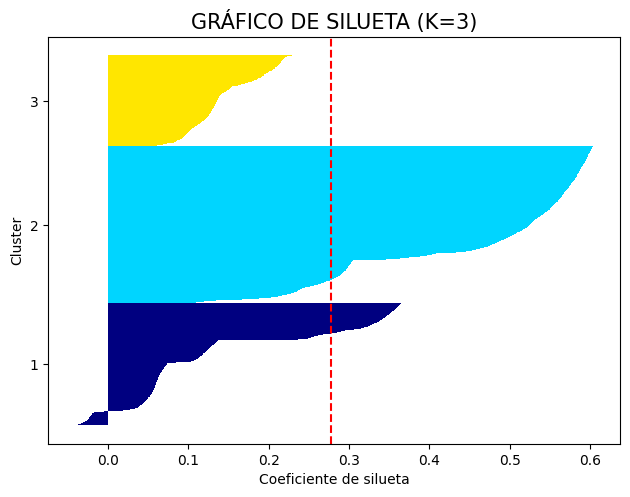

In [59]:
graficar_silueta(num_clusters=3)

Separar en 3 clusters no parece la mejor opción ya que el puntaje promedio (linea roja) es bastante bajo e incluso hay registros del cluster 1 con un puntaje negativo.

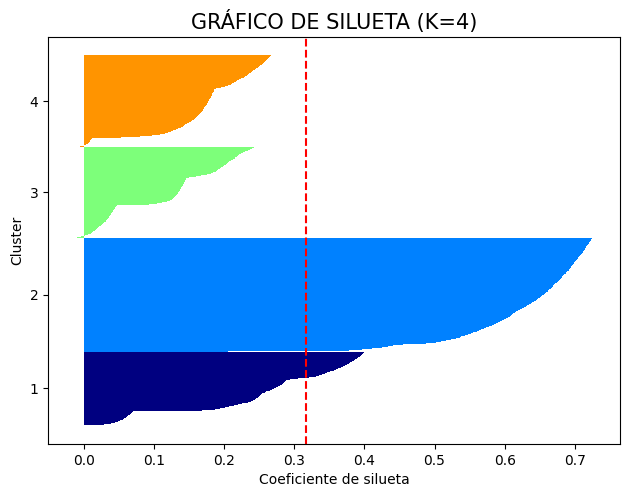

In [60]:
graficar_silueta(num_clusters=4)

Con 4 clusters el puntaje promedio mejora un poco, pero solo 2 clusters están por encima de este.

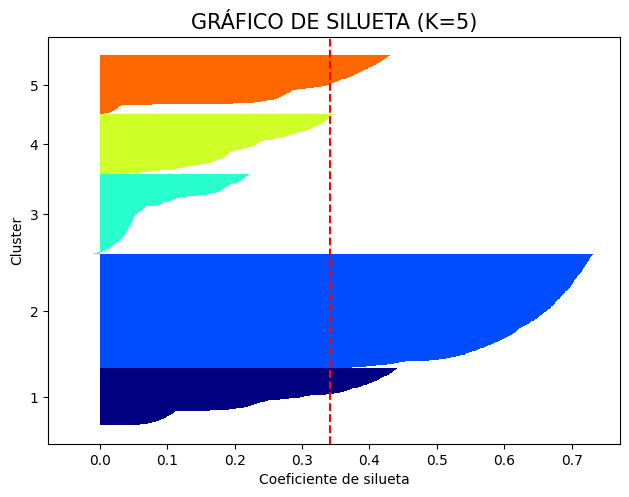

In [61]:
graficar_silueta(num_clusters=5)

Con 5 clusters el puntaje promedio es ligeramente mejor y además la mayoría de los clusters (4 de ellos) superan o alcanzan dicho promedio, por lo tanto parece ser la opción mas adecuada. 

Procederemos a entrenar el K-means con k=5 y agregaremos la etiqueta del cluster al dataset original.

In [62]:
# K-means con k=5
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

# Agregamos la columna cluster al dataset original
df['cluster'] = labels

### t-SNE

Ahora, para visualizar los clusters que se están formando haremos una reducción de dimensionalidad a 2 dimensiones.

In [63]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, init='random',perplexity=40, random_state=42)
X_digits_tsne = tsne.fit_transform(X)

In [64]:
import matplotlib.patheffects as PathEffects
def plot_projection(x, colors, ax=None):
    if ax is None:
        ax = plt.gca()
        
    num_clusters = len(np.unique(colors))
    
    for i in range(num_clusters):
        ax.scatter(x[colors == i, 0], x[colors == i, 1])
    
    for i in range(num_clusters):
        xtext, ytext = np.median(x[colors == i, :], axis=0)
        txt = ax.text(xtext, ytext, str(i), fontsize=24)
        txt.set_path_effects([
            PathEffects.Stroke(linewidth=5, foreground="w"),
            PathEffects.Normal()])
            
    ax.set_aspect('equal')

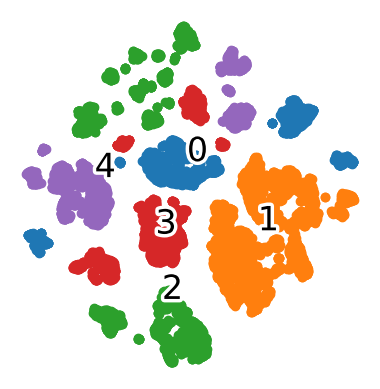

In [65]:
plot_projection(X_digits_tsne, labels)
plt.xticks([])
plt.yticks([])
plt.axis('off')
#plt.savefig('grafico_t-sne.png', dpi=300, bbox_inches='tight')
plt.show()

Esta proyección t-SNE nos muestra una clara separación de los núcleos de cada segmento. Las pequeñas dispersiones o sub-islas observadas
son consistentes con la naturaleza multimodal de las variables de sistemas operativos, el medio de tráfico y los navegadores.

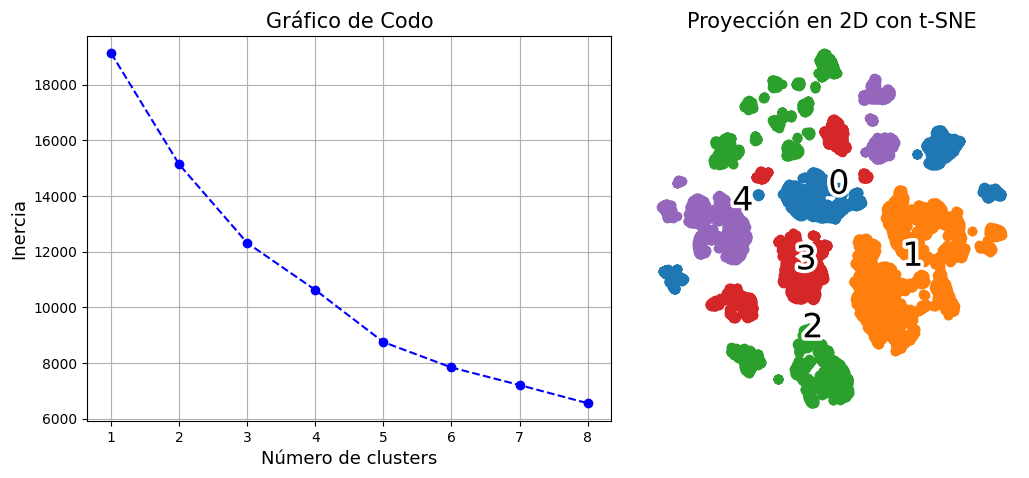

In [66]:
################## GRAFICO PARA EL INFORME ##################

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.3]})

# Codo
ax1.plot(range(1, 9), inertias, marker='o', c='b', linestyle='--')
ax1.set_xlabel('Número de clusters',fontsize=13)
ax1.set_ylabel('Inercia', fontsize=13)
ax1.set_title('Gráfico de Codo', fontsize=15)
ax1.grid(True)

# t-SNE
plot_projection(X_digits_tsne, labels, ax=ax2)
ax2.set_title('Proyección en 2D con t-SNE',fontsize=15)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.axis('off')

plt.subplots_adjust(wspace=-0.2)
#plt.savefig('grafico_codo_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

################## GRAFICO PARA EL INFORME ##################

## Análisis e Interpretación de Resultados

Realizaremos una agrupación por clusters para ver las características principales de cada uno.

In [67]:
df.groupby('cluster')['device_operatingSystem'].value_counts(normalize=True).unstack().fillna(0).round(2)

device_operatingSystem,Macintosh,Others,Windows
cluster,,,
0,0.00,0.00,1.00
1,1.00,0.00,0.00
2,0.00,1.00,0.00
3,0.55,0.17,0.28
4,1.00,0.00,0.00


Esta primera tabla nos permite ver lo siguiente: 
* El cluster 0 se compone únicamente de usuarios con sistema operativo Windows.
* Los clusters 1 y 4 se componen exclusivamente de usuarios de Macintosh. En la siguiente tabla veremos las características que los diferencian.
* El cluster 2 no contiene usarios ni Windows ni Macintosh y por lo tanto hace parte de grupos minoritarios como Linux, Chrome OS, etc.
* El cluster 3 se compone de usuarios repartidos en los diferentes sistemas operativos. 

In [68]:
df.groupby('cluster')['trafficSource_medium'].value_counts(normalize=True).unstack().fillna(0).round(2)

trafficSource_medium,direct,organic,paid,referral
cluster,,,,
0,0.00,0.66,0.09,0.25
1,0.00,0.00,0.00,1.00
2,0.11,0.38,0.09,0.41
3,1.00,0.00,0.00,0.00
4,0.00,0.83,0.17,0.00


Esta tabla nos muestra que:
* Los usuarios del cluster 0 (Windows) llegan al sitio web en mayor medida (66%) por busquedas orgánicas, seguido de referidos (25%).
* Los clusters 1 y 4 (Macintosh) se diferencian en que el 100% de usuarios del cluster 1 llegan por referidos, mientras que los del cluster 4 lo hacen por busquedas orgánicas (83%) y por publicidad (17%). Tambien cabe notar que los usuarios de este cluster (cluster 4) son los que mejor responden a las diferentes estrategias de publicidad en comparación a los otros clusters.
* El cluster 2 (aquellos de sistemas operativos minoritarios) llegan al sitio web en su mayoría por referidos (41%) y busquedas organicas (38%).
* El cluster 3 se compone de usuarios que llegan al sitio web exclusivamente por via directa.

In [69]:
df.groupby('cluster')['device_browser'].value_counts(normalize=True).unstack().fillna(0).round(2)

device_browser,Chrome,Others,Safari
cluster,,,
0,0.88,0.12,0.00
1,1.00,0.00,0.00
2,0.80,0.01,0.20
3,0.91,0.06,0.03
4,0.82,0.02,0.16


Esta tabla nos muestra principalmente que los usuarios del cluster 1 (Macintosh-referidos) acceden al sitio web únicamente desde el navegador Chrome, a diferencia de sus contrapartes del cluster 4 (Macintosh-orgánico/pago), donde vemos que un 16% utiliza Safari.

In [70]:
df.groupby('cluster')['device_category'].value_counts(normalize=True).unstack().fillna(0).round(2)

device_category,desktop,mobile,tablet
cluster,,,
0,0.99,0.00,0.00
1,1.00,0.00,0.00
2,0.56,0.36,0.07
3,1.00,0.00,0.00
4,1.00,0.00,0.00


Adicionalmente, esta tabla evidencia que los clusters 1 y 4 (usuarios Macintosh) acceden al sitio web únicamente mediante un computador de escritorio, al igual que los usuarios del cluster 3 (aquellos que llegan exclusivamente via directa).

Esto tambien evidencia que el cluster 1 es un grupo muy compacto, pues se compone en un 100% de usuarios Macintosh que llegan exclusivamente por referidos, desde un computador de escritorio y usando Chrome como navegador.

Por otro lado, resulta congruente que los usuarios del cluster 2 estén distribuidos en las 3 categorías y sean los únicos que acceden desde su teléfono personal, ya que, como se vio anteriormente, este grupo concentra los sistemas operativos móviles como iOS y Android.

In [71]:
df.groupby('cluster')[['weekend_prop','hour','totals_hits','totals_pageviews','bounce_prop']].mean().round()

,weekend_prop,hour,totals_hits,totals_pageviews,bounce_prop
cluster,,,,,
0,0.0,14.0,25.0,20.0,0.0
1,0.0,15.0,21.0,16.0,0.0
2,0.0,14.0,20.0,16.0,0.0
3,0.0,15.0,21.0,17.0,0.0
4,0.0,14.0,23.0,18.0,0.0


En cuanto a las variables numéricas, no se observan diferencias significativas entre los clusters. Cabe notar que el cluster 0 (Windows) presenta en promedio un total de interacciones y de paginas vistas superior al resto, pero la diferencia es mínima.